<a href="https://colab.research.google.com/github/amrloulah-dev/ML_Project/blob/main/ML_Promject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
#  نقوم بربط بيئة Colab بجوجل درايف للوصول لملف البيانات

from google.colab import drive
drive.mount('/content/drive')

# نقوم بفك ضغط ملف البيانات في المساحة المؤقتة لتسريع عملية القراءة
!unzip -q "/content/drive/MyDrive/ML_Project/archive.zip" -d "/content/dataset"

print("تم فك ضغط البيانات بنجاح.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
unzip:  cannot find or open /content/drive/MyDrive/ML_Project/archive.zip, /content/drive/MyDrive/ML_Project/archive.zip.zip or /content/drive/MyDrive/ML_Project/archive.zip.ZIP.
تم فك ضغط البيانات بنجاح.


In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# تحديد مسار مجلدات التدريب والاختبار
train_dir = '/content/dataset/seg_train/seg_train'
test_dir = '/content/dataset/seg_test/seg_test'

# تعريف الفئات الستة الموجودة في مجموعة البيانات
classes =['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# توحيد حجم الصور إلى 64x64 لتقليل العبء الحسابي على نماذج تعلم الآلة
IMG_SIZE = 64

In [17]:
def load_data(data_dir):
    X = []
    y = []

    for label in classes:
        path = os.path.join(data_dir, label)
        class_num = classes.index(label)

        # قراءة الصور ومعالجتها
        for img_name in tqdm(os.listdir(path), desc=f"Loading {label}"):
            try:
                img_path = os.path.join(path, img_name)
                img_array = cv2.imread(img_path)
                # تحويل نظام الألوان إلى RGB
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                # تغيير حجم الصورة
                resized_img = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

                X.append(resized_img)
                y.append(class_num)
            except Exception as e:
                pass

    return np.array(X), np.array(y)

print("جاري تحميل بيانات التدريب (Train Data)...")
X_train, y_train = load_data(train_dir)

print("\nجاري تحميل بيانات الاختبار (Test Data)...")
X_test, y_test = load_data(test_dir)

print(f"\nحجم بيانات التدريب: {X_train.shape}")
print(f"حجم بيانات الاختبار: {X_test.shape}")

جاري تحميل بيانات التدريب (Train Data)...


Loading street: 100%|██████████| 2382/2382 [00:01<00:00, 1858.30it/s]



جاري تحميل بيانات الاختبار (Test Data)...


Loading street: 100%|██████████| 501/501 [00:00<00:00, 806.35it/s]


حجم بيانات التدريب: (14034, 64, 64, 3)
حجم بيانات الاختبار: (3000, 64, 64, 3)


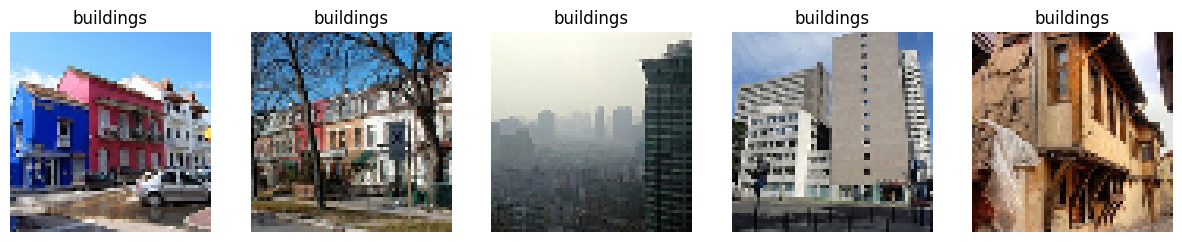

In [18]:
# عرض عينة عشوائية من البيانات للتأكد من صحة القراءة
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i]])
    plt.axis('off')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

# تقسيم بيانات التدريب إلى 80% تدريب و 20% تحقق (Validation) لتقييم النماذج
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print(f"حجم التدريب النهائي: {X_train_final.shape}")
print(f"حجم التحقق (Validation): {X_val.shape}")
print(f"حجم الاختبار (Test): {X_test.shape}")

حجم التدريب النهائي: (11227, 64, 64, 3)
حجم التحقق (Validation): (2807, 64, 64, 3)
حجم الاختبار (Test): (3000, 64, 64, 3)


In [20]:
from sklearn.preprocessing import StandardScaler

# تحويل مصفوفات الصور من 3D إلى 1D (Flattening) لتتوافق مع خوارزميات الـ ML
X_train_flat = X_train_final.reshape(X_train_final.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"أبعاد البيانات بعد عملية الـ Flattening: {X_train_flat.shape}")

# توحيد مقاييس البيانات (Scaling) لتحسين أداء النماذج
print("جاري توحيد مقاييس البيانات (Scaling)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

أبعاد البيانات بعد عملية الـ Flattening: (11227, 12288)
جاري توحيد مقاييس البيانات (Scaling)...


In [21]:
from sklearn.decomposition import PCA

# نستخدم تقنية PCA لتقليل الأبعاد واستخراج أهم 200 ميزة فقط لتجنب الـ Overfitting
n_components = 200
print(f"جاري تطبيق PCA لاستخراج أهم {n_components} ميزة...")

pca = PCA(n_components=n_components, random_state=42)

# تطبيق الاستخراج على مجموعات التدريب والتحقق والاختبار
X_train_features = pca.fit_transform(X_train_scaled)
X_val_features = pca.transform(X_val_scaled)
X_test_features = pca.transform(X_test_scaled)

print("تمت عملية استخراج الميزات (Feature Extraction) بنجاح.")
print(f"الأبعاد النهائية للبيانات: {X_train_features.shape}")

جاري تطبيق PCA لاستخراج أهم 200 ميزة...
تمت عملية استخراج الميزات (Feature Extraction) بنجاح.
الأبعاد النهائية للبيانات: (11227, 200)


In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("بدء تدريب نموذج SVM...")

# تهيئة وتدريب نموذج الدعم الآلي (Support Vector Machine)
svm_model = SVC(C=1.0, kernel='rbf', random_state=42)
svm_model.fit(X_train_features, y_train_final)

# تقييم مبدئي على بيانات التحقق
svm_val_preds = svm_model.predict(X_val_features)
svm_val_accuracy = accuracy_score(y_val, svm_val_preds)

print(f"تم تدريب SVM. دقة التحقق (Validation Accuracy): {svm_val_accuracy * 100:.2f}%")

بدء تدريب نموذج SVM...
تم تدريب SVM. دقة التحقق (Validation Accuracy): 64.91%


In [24]:
from sklearn.neighbors import KNeighborsClassifier

print("بدء تدريب نموذج KNN...")

# تهيئة وتدريب خوارزمية أقرب الجيران (K-Nearest Neighbors) باستخدام 5 جيران
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_features, y_train_final)

# تقييم مبدئي على بيانات التحقق
knn_val_preds = knn_model.predict(X_val_features)
knn_val_accuracy = accuracy_score(y_val, knn_val_preds)

print(f"تم تدريب KNN. دقة التحقق (Validation Accuracy): {knn_val_accuracy * 100:.2f}%")

بدء تدريب نموذج KNN...
تم تدريب KNN. دقة التحقق (Validation Accuracy): 48.98%


In [25]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- التقييم النهائي على بيانات الاختبار (Test Data) ---")

# استخراج توقعات النماذج
svm_test_preds = svm_model.predict(X_test_features)
knn_test_preds = knn_model.predict(X_test_features)

# عرض تقارير الأداء التفصيلية
print("\n1. تقرير أداء نموذج SVM:")
print(classification_report(y_test, svm_test_preds, target_names=classes))

print("\n---------------------------------------------------------")

print("\n2. تقرير أداء نموذج KNN:")
print(classification_report(y_test, knn_test_preds, target_names=classes))

--- التقييم النهائي على بيانات الاختبار (Test Data) ---

1. تقرير أداء نموذج SVM:
              precision    recall  f1-score   support

   buildings       0.54      0.47      0.50       437
      forest       0.78      0.81      0.79       474
     glacier       0.62      0.68      0.65       553
    mountain       0.61      0.67      0.64       525
         sea       0.60      0.44      0.51       510
      street       0.65      0.73      0.69       501

    accuracy                           0.64      3000
   macro avg       0.63      0.63      0.63      3000
weighted avg       0.63      0.64      0.63      3000


---------------------------------------------------------

2. تقرير أداء نموذج KNN:
              precision    recall  f1-score   support

   buildings       0.50      0.14      0.22       437
      forest       0.54      0.87      0.67       474
     glacier       0.53      0.51      0.52       553
    mountain       0.42      0.74      0.54       525
         sea       

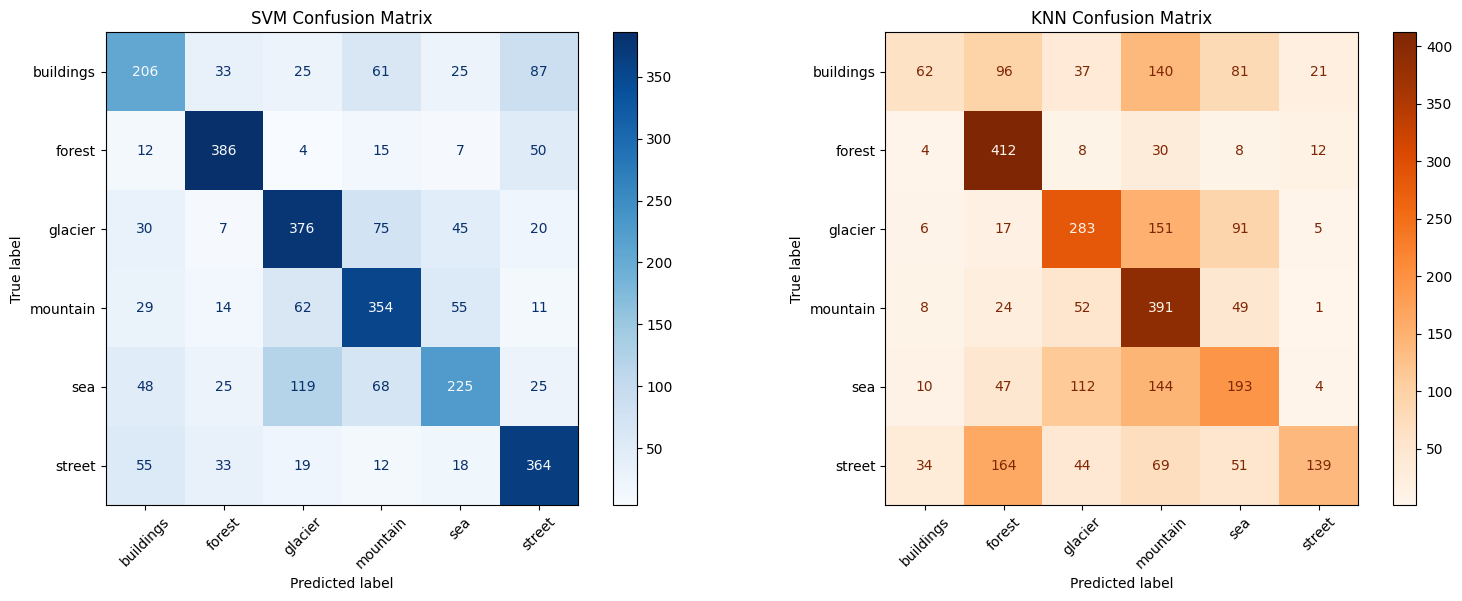

In [26]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# رسم مصفوفة الارتباك (Confusion Matrix) لمقارنة التوقعات بالنتائج الفعلية
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_svm = confusion_matrix(y_test, svm_test_preds)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=classes)
disp_svm.plot(ax=axes[0], cmap='Blues', xticks_rotation=45)
axes[0].set_title('SVM Confusion Matrix')

cm_knn = confusion_matrix(y_test, knn_test_preds)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=classes)
disp_knn.plot(ax=axes[1], cmap='Oranges', xticks_rotation=45)
axes[1].set_title('KNN Confusion Matrix')

plt.tight_layout()
plt.show()

رسم منحنيات التدريب (Learning Curves)...


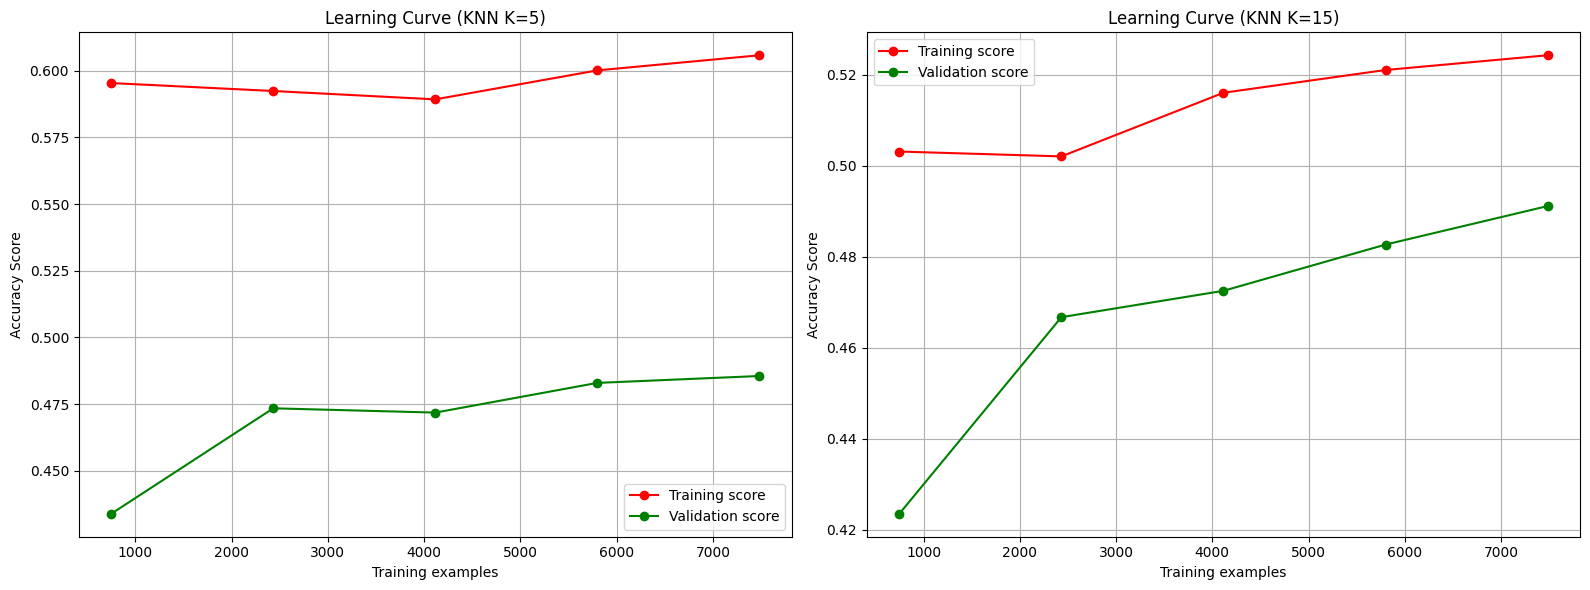

In [27]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ax):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation score")
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Accuracy Score")
    ax.legend(loc="best")
    ax.grid()

# رسم منحنيات التدريب لتحليل أداء النماذج مع زيادة حجم البيانات
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

print("رسم منحنيات التدريب (Learning Curves)...")

# نقوم برسم منحنى KNN مع قيمتين مختلفتين لـ K لملاحظة تأثيرها على التعميم
plot_learning_curve(KNeighborsClassifier(n_neighbors=5), "Learning Curve (KNN K=5)", X_train_features, y_train_final, axes[0])
plot_learning_curve(KNeighborsClassifier(n_neighbors=15), "Learning Curve (KNN K=15)", X_train_features, y_train_final, axes[1])

plt.tight_layout()
plt.show()